In [17]:
import pandas as pd
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'svg'
import numpy as np

In [27]:
# df_1 = pd.read_parquet("../experiments/scaling_laws/qwen3/gpt_oss_results/breast_cancer_recurrence_multi_model_predictor_answers_20_high.parquet")
# df_2 = pd.read_parquet("../experiments/scaling_laws/qwen3/gpt_oss_results/breast_cancer_recurrence_predictions_testabillity.parquet")
df_1 = pd.read_parquet("../experiments/breast_cancer/qwen_3/predictions.parquet")

In [36]:
df_1.columns

Index(['original_dataset', 'original_question', 'original_question_idx',
       'original_ground_truth', 'original_answer_first',
       'original_description', 'original_question_options',
       'original_reference_response_cot',
       'original_reference_response_raw_response',
       'original_reference_response_parsed_response',
       'original_reference_response_answer',
       'original_reference_response_model_info_model',
       'original_reference_response_model_info_temperature',
       'original_reference_response_model_info_max_tokens',
       'original_reference_response_model_info_thinking',
       'original_reference_response_model_info_seed',
       'original_reference_response_model_info_additional_params',
       'counterfactual_generator_model', 'counterfactual_generator_method',
       'counterfactual_question', 'counterfactual_generator_model_info',
       'counterfactual_generator_model_cot',
       'counterfactual_generator_model_raw', 'counterfactual_question

#### Old

In [34]:
confidences = []
matches_with = []
matches_without = []

for i in range(0, len(df_1)):
    with_ = df_1['counterfactual_predictor_response_with_explanation_parsed_response'][i]
    without_ = df_1['counterfactual_predictor_response_without_explanation_parsed_response'][i]
    reference_model_answer = df_1['counterfactual_reference_response_answer'][i]
    try:
        c = with_.get('confidence', None) if isinstance(with_, dict) else None
        a_with = with_.get('answer', None) if isinstance(with_, dict) else None
    except Exception:
        c = None
        a_with = None
    try:
        a_without = without_.get('answer', None) if isinstance(without_, dict) else None
    except Exception:
        a_without = None
    confidences.append(c)
    matches_with.append(a_with == reference_model_answer if a_with is not None else None)
    matches_without.append(a_without == reference_model_answer if a_without is not None else None)

df_1['confidence'] = confidences
df_1['match_with'] = matches_with
df_1['match_without'] = matches_without
df_1['match'] = df_1.apply(lambda x: x['counterfactual_predictor_response_with_explanation_answer']==x['counterfactual_reference_response_answer'], axis=1)


In [29]:
df = pd.DataFrame({"confidence": confidences, "correct": matches_with})
counts = pd.crosstab(df["confidence"], df["correct"])
print(counts)

# nice!

correct                                             False  True 
confidence                                                      
HIGH                                                  869   5573
HIGH – The absence of radiation, combined with ...      0      1
HIGH – The reasoning directly mirrors the refer...      1      0
HIGH – The reasoning directly mirrors the refer...      0      1
HIGH – the counterfactual patient’s profile is ...      0      1
HIGH – the patient’s profile matches the refere...      0      1
HIGH – the protective factors outweigh the mini...      0      1
MEDIUM                                               3093   4017
MEDIUM  \n\n---                                         4      4
MEDIUM  \n\n---  \n*The prediction follows the ...      1      0
MEDIUM  \n\n--- The prediction follows the othe...      1      0
MEDIUM  \n\nThe confidence is medium because wh...      1      0
MEDIUM  \n\nThe confidence is moderate because ...      0      1
MEDIUM  \n\nThe confidenc

In [30]:
df

,confidence,correct
0,HIGH,True
1,HIGH,True
2,HIGH,True
3,MEDIUM,False
4,HIGH,True
...,...,...
13651,MEDIUM,False
13652,HIGH,True
13653,MEDIUM,True
13654,MEDIUM,True


In [31]:
##############################
# significantly more accurate if you filter
##############################
df_high = df_1[df_1['confidence']=='HIGH']

predictor_accuracy_total = df_1['match'].mean().item()
predictor_accuracy_high = df_high['match'].mean().item()

print(predictor_accuracy_total)
print(predictor_accuracy_high)


df_high.groupby('original_reference_response_model_info_model')['match'].mean()

0.7057703573520797
0.8651040049674015


original_reference_response_model_info_model
Qwen/Qwen3-0.6B    0.962617
Qwen/Qwen3-1.7B    0.673591
Qwen/Qwen3-14B     0.930410
Qwen/Qwen3-32B     0.872232
Qwen/Qwen3-4B      0.859631
Qwen/Qwen3-8B      0.872038
Name: match, dtype: float64

In [35]:
def consistency(l):
    """normalised consistency of a list"""
    if l is None or len(l) == 0:
        return None  # or np.nan if you prefer
    
    # Filter out None values
    l_filtered = [x for x in l if x is not None]
    
    if len(l_filtered) == 0:
        return None  # or np.nan if you prefer
    
    c = pd.Series(l_filtered).value_counts(normalize=True).iloc[0]
    mi = 0.6
    ma = 1.0
    return float(max(0, (c-mi)/(ma-mi)))

df_1['consistency'] = df_1.apply(lambda x: consistency(x['counterfactual_predictor_response_with_explanation_repeated_answers']), axis=1)

KeyError: 'counterfactual_predictor_response_with_explanation_repeated_answers'

In [33]:

np.corrcoef(df_1['consistency'], df_1['counterfactual_predictor_counterfactual_testability_score'])
plt.hist(df_1['consistency'])

KeyError: 'consistency'

In [14]:
# positive score between testability score and model confidence.
df_1.groupby(['confidence'])['counterfactual_predictor_counterfactual_testability_score'].mean()

confidence
HIGH                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

#### New

In [9]:
# hist of testabilities
plt.hist(df_2['counterfactual_predictor_counterfactual_testability_score'])

NameError: name 'df_2' is not defined

13638


,match_without,match_with,diff,norm_diff
original_reference_response_model_info_model,,,,
Qwen/Qwen3-0.6B,0.561951,0.719244,0.157293,35.907723
Qwen/Qwen3-1.7B,0.590949,0.611160,0.020211,4.940924
Qwen/Qwen3-14B,0.673111,0.740773,0.067663,20.698925
Qwen/Qwen3-32B,0.581722,0.717926,0.136204,32.563025
Qwen/Qwen3-4B,0.681577,0.723649,0.042073,13.212796
Qwen/Qwen3-8B,0.667838,0.723199,0.055360,16.666667


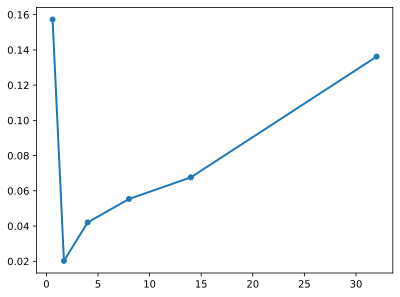

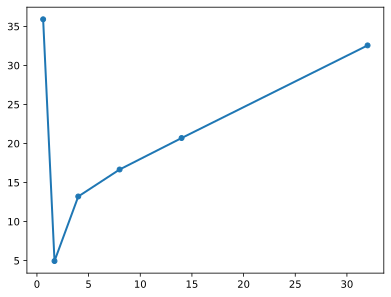

In [20]:
# set the filter
df_filters = df_2[df_2['counterfactual_predictor_counterfactual_testability_score']>=0].copy()
print(len(df_filters))

# calculate sim
df_filters['match_without'] = df_filters.apply(lambda row: row['counterfactual_predictor_response_without_explanation_answer']==row['counterfactual_reference_response_answer'], axis=1)
df_filters['match_with'] = df_filters.apply(lambda row: row['counterfactual_predictor_response_with_explanation_answer']==row['counterfactual_reference_response_answer'], axis=1)

# sim. I don't like these cases.
# print(df_2['match_without'].mean().item())
# print(df_2['match_with'].mean().item())

sim = df_filters.groupby(['original_reference_response_model_info_model'])[['match_without', 'match_with']].mean()

sim['diff'] = sim['match_with'] - sim['match_without']
sim['norm_diff'] = (sim['diff'] / (1-sim['match_without']))*100

display(sim)

param_sizes = {
    "Qwen/Qwen3-0.6B": 0.6,
    "Qwen/Qwen3-1.7B": 1.7,
    "Qwen/Qwen3-4B":   4.0,
    "Qwen/Qwen3-8B":   8.0,
    "Qwen/Qwen3-14B":  14.0,
    "Qwen/Qwen3-32B":  32.0,
}

sim["param_size_B"] = sim.index.map(param_sizes)

sim = sim.sort_values("param_size_B")

#display(sim)

plt.plot(sim.param_size_B, sim['diff'], marker="o",linewidth=2, markersize=5)
plt.show()

plt.plot(sim.param_size_B, sim['norm_diff'], marker="o",linewidth=2, markersize=5)
plt.show()

In [22]:
import numpy as np
np.corrcoef(df_filters['counterfactual_predictor_counterfactual_testability_score'], df_filters['match_with'])

array([[1.        , 0.12340002],
       [0.12340002, 1.        ]])